In [30]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [31]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [32]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.704374,-0.476099,-0.889800,-1.160454,-1.297609,0
1,0.464406,2.416462,-1.234198,2.107383,-0.562164,1
2,-0.915368,-1.192488,-0.292867,-1.881221,-1.383852,0
3,-0.420750,2.469741,-1.078030,0.828051,-0.218462,1
4,-1.412718,-3.370856,-1.408310,-1.228833,-0.643476,0


In [33]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [34]:
import random

In [35]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols].copy()
  new_df['target'] = df['target']
  return new_df

In [36]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [37]:
sample_rows(df,0.1)
# sample_features(df,0.5)

,col1,col2,col3,col4,col5,target
92,0.327292,2.139094,-2.444604,1.903375,0.201342,1
86,-2.292072,-0.687219,-1.612562,-2.354575,-0.130473,0
0,-2.704374,-0.476099,-0.889800,-1.160454,-1.297609,0
8,-1.184434,-0.174723,-0.641651,-1.978277,-1.465130,0
80,-0.678629,1.361720,0.985805,2.012475,-1.526164,1
62,-1.643545,1.706845,-0.206146,1.402036,-1.537119,1
97,-1.348045,1.243821,0.822594,1.102958,-1.938631,1
61,-0.552431,-2.043733,0.155830,-0.361959,-1.978799,0
82,-0.555256,-0.809592,0.000719,-0.193993,-2.476738,0
21,0.347285,-2.150549,-1.112970,-0.109021,-2.469360,0


In [38]:
df1 = combined_sampling(df,0.5,0.5)

In [39]:
df2 = combined_sampling(df,0.5,0.5)

In [40]:
df3 = combined_sampling(df,0.5,0.5)

In [41]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col2', 'target'], dtype='object')
Index(['col3', 'col4', 'target'], dtype='object')
Index(['col3', 'col5', 'target'], dtype='object')


In [42]:
df3

,col3,col5,target
79,-2.346276,-1.383641,0
19,-0.161381,-0.834107,1
92,-2.444604,0.201342,1
10,-2.435059,0.067032,1
79,-2.346276,-1.383641,0
25,0.592991,-0.742604,0
83,-0.111133,-1.649020,1
36,0.530720,-1.524603,0
30,-1.801631,-0.483247,0
10,-2.435059,0.067032,1


Using this combined sampling dataframes to train different classifier . we can train using row sampling, column sampling or like both that we are using 

In [43]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [44]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [45]:
from sklearn.tree import plot_tree

[Text(0.47058823529411764, 0.9, 'x[1] <= -0.367\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.23529411764705882, 0.7, 'x[1] <= -2.235\ngini = 0.172\nsamples = 21\nvalue = [19, 2]'),
 Text(0.3529411764705882, 0.8, 'True  '),
 Text(0.11764705882352941, 0.5, 'x[0] <= -0.896\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.058823529411764705, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.17647058823529413, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.35294117647058826, 0.5, 'x[0] <= 0.265\ngini = 0.111\nsamples = 17\nvalue = [16, 1]'),
 Text(0.29411764705882354, 0.3, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.4117647058823529, 0.3, 'x[0] <= 0.308\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.35294117647058826, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.47058823529411764, 0.1, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.7058823529411765, 0.7, 'x[0] <= -2.191\ngini = 0.185\nsamples = 29\nvalue = [3, 26]'),
 T

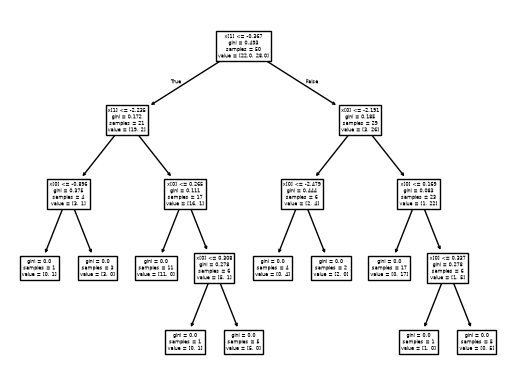

In [46]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[1] <= 0.375\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 27\nvalue = [27, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 23\nvalue = [0, 23]'),
 Text(0.625, 0.5, '  False')]

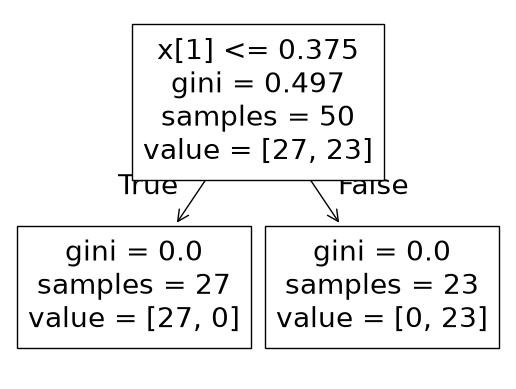

In [47]:
plot_tree(clf2)

[Text(0.4868421052631579, 0.9285714285714286, 'x[0] <= 0.674\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.4342105263157895, 0.7857142857142857, 'x[1] <= -1.113\ngini = 0.496\nsamples = 46\nvalue = [25, 21]'),
 Text(0.4605263157894737, 0.8571428571428572, 'True  '),
 Text(0.21052631578947367, 0.6428571428571429, 'x[0] <= -0.219\ngini = 0.36\nsamples = 17\nvalue = [13, 4]'),
 Text(0.10526315789473684, 0.5, 'x[1] <= -1.259\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.05263157894736842, 0.35714285714285715, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.15789473684210525, 0.35714285714285715, 'x[0] <= -1.49\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.10526315789473684, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.21052631578947367, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.3157894736842105, 0.5, 'x[0] <= 0.511\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.2631578947368421, 0.35714285714285

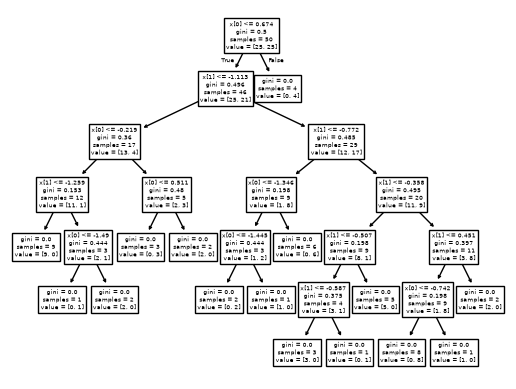

In [48]:
plot_tree(clf3)

we can see we are creating different tree due to bagging approach 

In [49]:
clf1.predict(np.array([-1.548743	,-0.387546]).reshape(1,2))

/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [50]:
clf2.predict(np.array([-1.548743	,-0.387546]).reshape(1,2))

/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [51]:
clf3.predict(np.array([-1.548743	,-0.387546]).reshape(1,2))

/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

So we will select 1 as all of our 3 classifier said it is 1 

In [52]:
# 1.809826	0.614932	0

print(clf1.predict(np.array([1.809826,	0.614932]).reshape(1,2)))
print(clf2.predict(np.array([1.809826,	0.614932]).reshape(1,2)))
print(clf3.predict(np.array([1.809826,	0.614932]).reshape(1,2)))


[1]
[1]
[1]


/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


As 2 out of 3 classifer is predicting 0 so class 0 is selected as per majority counting 

In [53]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
24,-0.432093,-0.659808,-1.755618,1.570667,-1.219817,1
95,-1.224225,1.451617,-0.644781,0.843226,-1.103469,1
80,-0.678629,1.361720,0.985805,2.012475,-1.526164,1
31,-3.386448,-1.134964,-2.820293,-2.713131,0.836309,0
14,-3.981749,1.317070,-1.811348,-0.590918,-1.431370,1
16,0.107854,1.698302,0.458066,2.292529,-1.738402,1
85,-0.311538,-0.286057,-1.779219,1.734338,-0.572645,1
31,-3.386448,-1.134964,-2.820293,-2.713131,0.836309,0
9,-1.305000,-1.609684,-0.881652,-1.811530,-0.425955,0
99,1.344144,0.926873,0.556517,-0.622251,-2.674427,0
